In [200]:
import os

import ast
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["WANDB_API_KEY"] = (
    ""
)



In [201]:
# Cell 1: load runs into a DataFrame
import pandas as pd
import numpy as np
import wandb

api = wandb.Api()

PROJECT = "julian_oelhaf/fc-fl-comparison"
runs = api.runs(PROJECT)

records = []
for run in runs:
    summary = run.summary._json_dict
    config = {k: v for k, v in run.config.items() if not k.startswith("_")}

    record = {
        "run_id": run.id,
        "run_name": run.name,
        "state": run.state,
        "created_at": run.created_at,
        "group": run.group,
        "job_type": run.job_type,
        "tags": ",".join(run.tags) if run.tags else "",
    }

    record.update({f"summary.{k}": v for k, v in summary.items()})
    record.update({f"config.{k}": v for k, v in config.items()})

    records.append(record)

runs_df = pd.DataFrame(records)
runs_df = runs_df[runs_df["state"] == "finished"].copy()

print(f"Loaded {len(runs_df)} finished runs")
print(runs_df.shape)

Loaded 574 finished runs
(574, 126)


In [202]:
runs_df

,run_id,run_name,state,created_at,group,job_type,tags,summary._runtime,summary._step,summary._timestamp,...,summary.runtime/predict_single_mean_s/std,summary.runtime/predict_single_std_s/mean,summary.runtime/predict_single_std_s/std,summary.runtime/predict_throughput_samples_per_s/mean,summary.runtime/predict_throughput_samples_per_s/std,summary.runtime/scaler_fit_transform_train_s/mean,summary.runtime/scaler_fit_transform_train_s/std,summary.runtime/scaler_transform_test_s/mean,summary.runtime/scaler_transform_test_s/std,config.runtime_protocol
0,3kt9ysi5,snowy-bee-134,finished,2026-01-21T09:43:37Z,None,None,,384.0,0.0,1.768989e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9knh61ij,fiery-glade-135,finished,2026-01-21T09:48:44Z,None,None,,339.0,0.0,1.768989e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ibj0j5wf,vague-haze-137,finished,2026-01-21T09:54:50Z,None,None,,397.0,0.0,1.768990e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,grxutsz8,efficient-feather-138,finished,2026-01-21T09:58:59Z,None,None,,712.0,0.0,1.768990e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,vku5ihg1,sleek-microwave-139,finished,2026-01-21T10:01:52Z,None,None,,451.0,0.0,1.768990e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590,jo4u7jxd,usual-durian-859,finished,2026-04-20T10:56:44Z,None,None,,488.0,4.0,1.776683e+09,...,0.000517,0.000073,0.000053,31277.287367,8542.249739,9.047417,1.265025,0.643260,0.010995,"{'cpu': 'x86_64', 'scope': 'relative_cpu_side_..."
591,gncblfay,bumbling-pyramid-860,finished,2026-04-20T11:05:46Z,None,None,,7991.0,4.0,1.776691e+09,...,0.000009,0.000044,0.000019,132184.667257,12243.959943,8.601511,1.294458,0.625841,0.033278,"{'cpu': 'x86_64', 'scope': 'relative_cpu_side_..."
592,62fq96jp,eager-microwave-861,finished,2026-04-20T11:11:47Z,None,None,,3589.0,13.0,1.776687e+09,...,0.000312,0.000688,0.000132,11988.236721,2061.343483,20.531439,0.499489,1.565497,0.102707,"{'cpu': 'x86_64', 'scope': 'relative_cpu_side_..."
593,58fj4vcq,fast-salad-862,finished,2026-04-20T11:57:14Z,None,None,,3579.0,13.0,1.776690e+09,...,0.000002,0.000034,0.000003,165976.803084,8908.220459,18.456580,0.911734,1.403762,0.020178,"{'cpu': 'x86_64', 'scope': 'relative_cpu_side_..."


In [203]:
# Cell 2: flatten runtime protocol and filter to runs that actually contain runtime measurements
def flatten_dict_column(df: pd.DataFrame, col: str, prefix: str) -> pd.DataFrame:
    if col not in df.columns:
        return df

    is_dict = df[col].apply(lambda x: isinstance(x, dict))
    if not is_dict.any():
        return df

    expanded = pd.json_normalize(df.loc[is_dict, col]).add_prefix(f"{prefix}.")
    expanded.index = df.loc[is_dict].index
    out = df.copy()
    out = out.join(expanded)
    return out


runs_df_flattened = flatten_dict_column(
    runs_df, "config.runtime_protocol", "config.runtime_protocol"
)

runtime_scope_col = "config.runtime_protocol.scope"
completed_col = "summary.completed"

has_runtime_protocol = runs_df_flattened.get(
    "config.runtime_protocol", pd.Series(index=runs_df_flattened.index, dtype=object)
).apply(lambda x: isinstance(x, dict))

runtime_runs = runs_df_flattened.loc[has_runtime_protocol].copy()

if runtime_scope_col in runtime_runs.columns:
    runtime_runs = runtime_runs[
        runtime_runs[runtime_scope_col] == "relative_cpu_side_model_runtime_only"
    ].copy()

if completed_col in runtime_runs.columns:
    runtime_runs = runtime_runs[runtime_runs[completed_col] == True].copy()

print(f"Runtime runs: {len(runtime_runs)}")
display(
    runtime_runs[
        [
            c
            for c in [
                "run_id",
                "run_name",
                "config.model/name",
                "config.task/target_label",
                "config.dataset/topology",
                "config.window/length_s",
                "config.runtime_protocol.scope",
            ]
            if c in runtime_runs.columns
        ]
    ].head()
)

Runtime runs: 22


,run_id,run_name,config.model/name,config.task/target_label,config.dataset/topology,config.window/length_s,config.runtime_protocol.scope
573,b6d0gubt,apricot-wildflower-842,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.02,relative_cpu_side_model_runtime_only
574,14xj0s6r,confused-wind-843,mlp_classifier,event_type,hv_double_line_90kv,0.02,relative_cpu_side_model_runtime_only
575,e1ukou0m,driven-dust-844,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.01,relative_cpu_side_model_runtime_only
576,b7ote1gc,distinctive-morning-845,hist_gradient_boosting_regressor,y_fault_location,hv_double_line_90kv,0.01,relative_cpu_side_model_runtime_only
577,klj7ybr7,serene-jazz-846,mlp_regressor,y_fault_location,hv_double_line_90kv,0.01,relative_cpu_side_model_runtime_only


In [204]:
# Cell 3: inspect available runtime columns
runtime_cols = [c for c in runtime_runs.columns if c.startswith("summary.runtime/")]
print(runtime_cols)

['summary.runtime/model_fit_s/mean', 'summary.runtime/model_fit_s/std', 'summary.runtime/predict_batch_mean_s/mean', 'summary.runtime/predict_batch_mean_s/std', 'summary.runtime/predict_batch_per_sample_mean_s/mean', 'summary.runtime/predict_batch_per_sample_mean_s/std', 'summary.runtime/predict_batch_per_sample_std_s/mean', 'summary.runtime/predict_batch_per_sample_std_s/std', 'summary.runtime/predict_batch_std_s/mean', 'summary.runtime/predict_batch_std_s/std', 'summary.runtime/predict_full_test_once_s/mean', 'summary.runtime/predict_full_test_once_s/std', 'summary.runtime/predict_single_mean_s/mean', 'summary.runtime/predict_single_mean_s/std', 'summary.runtime/predict_single_std_s/mean', 'summary.runtime/predict_single_std_s/std', 'summary.runtime/predict_throughput_samples_per_s/mean', 'summary.runtime/predict_throughput_samples_per_s/std', 'summary.runtime/scaler_fit_transform_train_s/mean', 'summary.runtime/scaler_fit_transform_train_s/std', 'summary.runtime/scaler_transform_tes

In [205]:
# Cell 4: build one lean runtime table
meta_cols = [
    "run_id",
    "run_name",
    "config.model/name",
    "config.task/target_label",
    "config.dataset/topology",
    "config.window/length_s",
]

keep_runtime_cols = [
    "summary.runtime/model_fit_s/mean",
    "summary.runtime/model_fit_s/std",
    "summary.runtime/predict_single_mean_s/mean",
    "summary.runtime/predict_single_mean_s/std",
    "summary.runtime/predict_batch_per_sample_mean_s/mean",
    "summary.runtime/predict_batch_per_sample_mean_s/std",
    "summary.runtime/predict_throughput_samples_per_s/mean",
    "summary.runtime/predict_throughput_samples_per_s/std",
]

keep_cols = [c for c in meta_cols + keep_runtime_cols if c in runtime_runs.columns]

runtime_eval = runtime_runs[keep_cols].copy()

for col in runtime_eval.columns:
    if col.startswith("summary.runtime/") or col == "config.window/length_s":
        runtime_eval[col] = pd.to_numeric(runtime_eval[col], errors="coerce")

# nicer units
if "summary.runtime/model_fit_s/mean" in runtime_eval.columns:
    runtime_eval["fit_time_ms"] = 1000 * runtime_eval["summary.runtime/model_fit_s/mean"]

if "summary.runtime/predict_single_mean_s/mean" in runtime_eval.columns:
    runtime_eval["predict_single_ms"] = 1000 * runtime_eval["summary.runtime/predict_single_mean_s/mean"]

if "summary.runtime/predict_batch_per_sample_mean_s/mean" in runtime_eval.columns:
    runtime_eval["predict_batch_per_sample_us"] = 1e6 * runtime_eval["summary.runtime/predict_batch_per_sample_mean_s/mean"]

runtime_eval = runtime_eval.sort_values(
    ["config.task/target_label", "config.window/length_s", "config.model/name"]
)

display(runtime_eval)

,run_id,run_name,config.model/name,config.task/target_label,config.dataset/topology,config.window/length_s,summary.runtime/model_fit_s/mean,summary.runtime/model_fit_s/std,summary.runtime/predict_single_mean_s/mean,summary.runtime/predict_single_mean_s/std,summary.runtime/predict_batch_per_sample_mean_s/mean,summary.runtime/predict_batch_per_sample_mean_s/std,summary.runtime/predict_throughput_samples_per_s/mean,summary.runtime/predict_throughput_samples_per_s/std,fit_time_ms,predict_single_ms,predict_batch_per_sample_us
575,e1ukou0m,driven-dust-844,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.01,29.312637,1.018017,0.001654,0.000013,0.000008,8.948313e-08,132555.388562,1581.258674,2.931264e+04,1.654012,7.544870
578,rpba0zqb,whole-shadow-847,mlp_classifier,event_type,hv_double_line_90kv,0.01,144.435392,21.719799,0.000125,0.000002,0.000002,2.618747e-08,618108.133805,9910.260178,1.444354e+05,0.125013,1.618176
573,b6d0gubt,apricot-wildflower-842,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.02,72.808768,9.806206,0.002758,0.000743,0.000011,1.014285e-06,93583.906222,8978.392383,7.280877e+04,2.758375,10.763235
581,3f0212bu,honest-music-850,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.02,70.974917,8.828408,0.002894,0.000813,0.000010,1.239858e-06,96429.918481,11302.327734,7.097492e+04,2.894478,10.486194
574,14xj0s6r,confused-wind-843,mlp_classifier,event_type,hv_double_line_90kv,0.02,426.816466,20.138282,0.000122,0.000007,0.000003,1.611312e-07,317511.498026,15917.109494,4.268165e+05,0.122397,3.155953
582,m24x8p11,ethereal-dawn-851,mlp_classifier,event_type,hv_double_line_90kv,0.02,419.682422,25.115729,0.000727,0.001357,0.000003,3.526083e-07,322747.835383,32223.623769,4.196824e+05,0.726609,3.126524
585,ru71oe2n,absurd-energy-854,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.03,482.977366,71.515471,0.018165,0.000793,0.000056,7.340692e-07,17816.668479,230.416053,4.829774e+05,18.165347,56.134810
588,eeqd7hwj,smooth-night-857,mlp_classifier,event_type,hv_double_line_90kv,0.03,442.955461,74.631901,0.000139,0.000005,0.000005,2.773185e-07,217003.120061,12149.619797,4.429555e+05,0.139327,4.620646
589,738tjx9s,still-smoke-858,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.04,812.161271,123.043558,0.022939,0.005504,0.000082,1.259166e-05,12386.211648,1643.520945,8.121613e+05,22.939434,82.067717
593,58fj4vcq,fast-salad-862,mlp_classifier,event_type,hv_double_line_90kv,0.04,690.659138,196.877865,0.000170,0.000002,0.000006,3.465998e-07,165976.803084,8908.220459,6.906591e+05,0.169926,6.039816


In [206]:
# Cell 5: compact grouped summary across repeated runs
group_cols = [
    "config.model/name",
    "config.task/target_label",
    "config.dataset/topology",
    "config.window/length_s",
]

summary_cols = [
    c
    for c in [
        "fit_time_ms",
        "predict_single_ms",
        "predict_batch_per_sample_us",
        "summary.runtime/predict_throughput_samples_per_s/mean",
    ]
    if c in runtime_eval.columns
]

runtime_summary = (
    runtime_eval.groupby(group_cols, dropna=False)[summary_cols]
    .agg(["mean", "std", "count"])
    .round(3)
)

display(runtime_summary)

fit_time_ms  \
                                                                                                                  mean   
config.model/name                 config.task/target_label config.dataset/topology config.window/length_s                
hist_gradient_boosting_classifier event_type               hv_double_line_90kv     0.01                      29312.637   
                                                                                   0.02                      71891.842   
                                                                                   0.03                     482977.366   
                                                                                   0.04                     812161.271   
                                                                                   0.05                     673508.842   
hist_gradient_boosting_regressor  y_fault_location         hv_double_line_90kv     0.01                      12070.543   
                                                                                   0.02                      22990.697   
                                                                                   0.03                      40202.447   
                                                                                   0.04                      59972.055   
                                                                                   0.05                      81607.852   
mlp_classifier                    event_type               hv_double_line_90kv     0.01                     144435.392   
                                                                                   0.02                     423249.444   
                                                                                   0.03                     442955.461   
                                                                                   0.04                     690659.138   
                                                                                   0.05                     964698.269   
mlp_regressor                     y_fault_location         hv_double_line_90kv     0.01                      40850.568   
                                                                                   0.02                     190875.876   
                                                                                   0.03                     470859.649   
                                                                                   0.04                     951372.974   
                                                                                   0.05                    1585957.560   

                                                                                                                     \
                                                                                                                std   
config.model/name                 config.task/target_label config.dataset/topology config.window/length_s             
hist_gradient_boosting_classifier event_type               hv_double_line_90kv     0.01                         NaN   
                                                                                   0.02                    1296.728   
                                                                                   0.03                         NaN   
                                                                                   0.04                         NaN   
                                                                                   0.05                         NaN   
hist_gradient_boosting_regressor  y_fault_location         hv_double_line_90kv     0.01                         NaN   
                                                                                   0.02                         NaN   
                                                                                   0.03                       

In [207]:
# Cell 6: optional pivot for easiest paper-style comparison
metric = "predict_batch_per_sample_us"  # or "fit_time_ms", "predict_single_ms"

pivot = runtime_eval.pivot_table(
    index="config.model/name",
    columns="config.window/length_s",
    values=metric,
    aggfunc="mean",
)

display(pivot.round(3))

config.window/length_s,0.01,0.02,0.03,0.04,0.05
config.model/name,,,,,
hist_gradient_boosting_classifier,7.545,10.625,56.135,82.068,86.055
hist_gradient_boosting_regressor,15.249,15.233,21.754,29.434,35.280
mlp_classifier,1.618,3.141,4.621,6.040,7.629
mlp_regressor,1.404,3.092,5.247,6.208,7.617


In [208]:
# Cell A: helpers + clean table
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def pick_first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def make_runtime_perf_table(df):
    out = df.copy()

    # metadata
    meta_cols = [
        "run_id",
        "run_name",
        "config.model/name",
        "config.task/target_label",
        "config.dataset/topology",
        "config.window/length_s",
    ]
    meta_cols = [c for c in meta_cols if c in out.columns]

    # runtime columns
    fit_col = pick_first_existing(
        out,
        [
            "summary.runtime/model_fit_s/mean",
        ],
    )
    fit_std_col = pick_first_existing(
        out,
        [
            "summary.runtime/model_fit_s/std",
        ],
    )
    pred_col = pick_first_existing(
        out,
        [
            "summary.runtime/predict_batch_per_sample_mean_s/mean",
        ],
    )
    pred_std_col = pick_first_existing(
        out,
        [
            "summary.runtime/predict_batch_per_sample_mean_s/std",
        ],
    )
    thr_col = pick_first_existing(
        out,
        [
            "summary.runtime/predict_throughput_samples_per_s/mean",
        ],
    )
    thr_std_col = pick_first_existing(
        out,
        [
            "summary.runtime/predict_throughput_samples_per_s/std",
        ],
    )

    # performance columns (robust to slightly different naming)
    f1_col = pick_first_existing(
        out,
        [
            "summary.cv/mean_f1_score",
        ],
    )
    f1_std_col = pick_first_existing(
        out,
        [
            "summary.cv/std_f1_score",
        ],
    )
    mae_col = pick_first_existing(
        out,
        [
            "summary.cv/mean_mae",
        ],
    )
    mae_std_col = pick_first_existing(
        out,
        [
            "summary.cv/std_mae",
        ],
    )

    keep = meta_cols + [
        c
        for c in [
            fit_col,
            fit_std_col,
            pred_col,
            pred_std_col,
            thr_col,
            thr_std_col,
            f1_col,
            f1_std_col,
            mae_col,
            mae_std_col,
        ]
        if c is not None
    ]

    out = out[keep].copy()

    for c in out.columns:
        if c.startswith("summary.") or c == "config.window/length_s":
            out[c] = pd.to_numeric(out[c], errors="coerce")

    # nice units
    if fit_col:
        out["fit_time_s"] = out[fit_col]
    if fit_std_col:
        out["fit_time_s_std"] = out[fit_std_col]

    if pred_col:
        out["infer_us_per_window"] = 1e6 * out[pred_col]
    if pred_std_col:
        out["infer_us_per_window_std"] = 1e6 * out[pred_std_col]

    if thr_col:
        out["throughput_windows_per_s"] = out[thr_col]
    if thr_std_col:
        out["throughput_windows_per_s_std"] = out[thr_std_col]

    if f1_col:
        out["macro_f1"] = out[f1_col]
    if f1_std_col:
        out["macro_f1_std"] = out[f1_std_col]

    if mae_col:
        out["mae"] = out[mae_col]
    if mae_std_col:
        out["mae_std"] = out[mae_std_col]

    return out


runtime_eval = make_runtime_perf_table(runtime_runs)
display(runtime_eval)

,run_id,run_name,config.model/name,config.task/target_label,config.dataset/topology,config.window/length_s,summary.runtime/model_fit_s/mean,summary.runtime/model_fit_s/std,summary.runtime/predict_batch_per_sample_mean_s/mean,summary.runtime/predict_batch_per_sample_mean_s/std,...,fit_time_s,fit_time_s_std,infer_us_per_window,infer_us_per_window_std,throughput_windows_per_s,throughput_windows_per_s_std,macro_f1,macro_f1_std,mae,mae_std
573,b6d0gubt,apricot-wildflower-842,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.02,72.808768,9.806206,0.000011,1.014285e-06,...,72.808768,9.806206,10.763235,1.014285,93583.906222,8978.392383,0.738005,0.022940,NaN,NaN
574,14xj0s6r,confused-wind-843,mlp_classifier,event_type,hv_double_line_90kv,0.02,426.816466,20.138282,0.000003,1.611312e-07,...,426.816466,20.138282,3.155953,0.161131,317511.498026,15917.109494,0.992808,0.001717,NaN,NaN
575,e1ukou0m,driven-dust-844,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.01,29.312637,1.018017,0.000008,8.948313e-08,...,29.312637,1.018017,7.544870,0.089483,132555.388562,1581.258674,0.418111,0.008956,NaN,NaN
576,b7ote1gc,distinctive-morning-845,hist_gradient_boosting_regressor,y_fault_location,hv_double_line_90kv,0.01,12.070543,0.368189,0.000015,3.060219e-06,...,12.070543,0.368189,15.248655,3.060219,67365.292461,11208.923106,NaN,NaN,14.646097,0.185526
577,klj7ybr7,serene-jazz-846,mlp_regressor,y_fault_location,hv_double_line_90kv,0.01,40.850568,1.798571,0.000001,9.102206e-08,...,40.850568,1.798571,1.404210,0.091022,714375.846686,43050.196489,NaN,NaN,10.661781,0.393425
578,rpba0zqb,whole-shadow-847,mlp_classifier,event_type,hv_double_line_90kv,0.01,144.435392,21.719799,0.000002,2.618747e-08,...,144.435392,21.719799,1.618176,0.026187,618108.133805,9910.260178,0.989434,0.003359,NaN,NaN
579,b6m4vi6y,solar-sunset-848,hist_gradient_boosting_regressor,y_fault_location,hv_double_line_90kv,0.02,22.990697,0.487457,0.000015,1.536686e-06,...,22.990697,0.487457,15.233274,1.536686,66132.080765,6038.570296,NaN,NaN,14.783462,0.251678
580,2qsywy0n,happy-star-849,mlp_regressor,y_fault_location,hv_double_line_90kv,0.02,190.875876,32.320557,0.000003,8.352767e-07,...,190.875876,32.320557,3.092180,0.835277,338209.953465,68832.725149,NaN,NaN,10.195141,0.371722
581,3f0212bu,honest-music-850,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.02,70.974917,8.828408,0.000010,1.239858e-06,...,70.974917,8.828408,10.486194,1.239858,96429.918481,11302.327734,0.738005,0.022940,NaN,NaN
582,m24x8p11,ethereal-dawn-851,mlp_classifier,event_type,hv_double_line_90kv,0.02,419.682422,25.115729,0.000003,3.526083e-07,...,419.682422,25.115729,3.126524,0.352608,322747.835383,32223.623769,0.992808,0.001717,NaN,NaN


In [209]:
# Cell B alternative: keep only first entry per model/task/topology/window
key_cols = [
    c
    for c in [
        "config.model/name",
        "config.task/target_label",
        "config.dataset/topology",
        "config.window/length_s",
    ]
    if c in runtime_eval.columns
]

cols = key_cols + [
    c
    for c in [
        "fit_time_s",
        "infer_us_per_window",
        "throughput_windows_per_s",
        "summary.cv/mean_f1_score",
        "summary.cv/std_f1_score",
        "summary.cv/mean_mae",
        "summary.cv/std_mae",
    ]
    if c in runtime_eval.columns
]

paper_table = (
    runtime_eval[cols]
    .drop_duplicates(subset=key_cols, keep="first")
    .copy()
    .round(3)
    .sort_values(key_cols)
)

display(paper_table)

,config.model/name,config.task/target_label,config.dataset/topology,config.window/length_s,fit_time_s,infer_us_per_window,throughput_windows_per_s,summary.cv/mean_f1_score,summary.cv/std_f1_score,summary.cv/mean_mae,summary.cv/std_mae
575,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.01,29.313,7.545,132555.389,0.418,0.009,NaN,NaN
573,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.02,72.809,10.763,93583.906,0.738,0.023,NaN,NaN
585,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.03,482.977,56.135,17816.668,0.977,0.002,NaN,NaN
589,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.04,812.161,82.068,12386.212,0.982,0.002,NaN,NaN
592,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.05,673.509,86.055,11988.237,0.982,0.002,NaN,NaN
576,hist_gradient_boosting_regressor,y_fault_location,hv_double_line_90kv,0.01,12.071,15.249,67365.292,NaN,NaN,14.646,0.186
579,hist_gradient_boosting_regressor,y_fault_location,hv_double_line_90kv,0.02,22.991,15.233,66132.081,NaN,NaN,14.783,0.252
583,hist_gradient_boosting_regressor,y_fault_location,hv_double_line_90kv,0.03,40.202,21.754,47660.142,NaN,NaN,14.642,0.182
586,hist_gradient_boosting_regressor,y_fault_location,hv_double_line_90kv,0.04,59.972,29.434,34945.381,NaN,NaN,14.590,0.192
590,hist_gradient_boosting_regressor,y_fault_location,hv_double_line_90kv,0.05,81.608,35.280,31277.287,NaN,NaN,14.658,0.204


In [218]:
# Cell C: compact formatted tables per task
grouped = runtime_eval.groupby(group_cols, dropna=False)

rows = []
for keys, g in grouped:
    row = dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))

    if "fit_time_s" in g.columns:
        row["fit_time_s"] = (
            f"{g['fit_time_s'].mean():.3f} ± {g['fit_time_s'].std(ddof=1):.3f}"
            if len(g) > 1
            else f"{g['fit_time_s'].iloc[0]:.3f}"
        )

    if "infer_us_per_window" in g.columns:
        row["infer_us_per_window"] = (
            f"{g['infer_us_per_window'].mean():.3f} ± {g['infer_us_per_window'].std(ddof=1):.3f}"
            if len(g) > 1
            else f"{g['infer_us_per_window'].iloc[0]:.3f}"
        )

    if "throughput_windows_per_s" in g.columns:
        row["throughput_windows_per_s"] = (
            f"{g['throughput_windows_per_s'].mean():.1f} ± {g['throughput_windows_per_s'].std(ddof=1):.1f}"
            if len(g) > 1
            else f"{g['throughput_windows_per_s'].iloc[0]:.1f}"
        )

    if "summary.cv/mean_f1_score" in g.columns:
        f1_mean = g["summary.cv/mean_f1_score"].mean()
        if "summary.cv/std_f1_score" in g.columns:
            f1_std = g["summary.cv/std_f1_score"].mean()
            row["macro_f1"] = f"{f1_mean:.3f} ± {f1_std:.3f}"
        else:
            row["macro_f1"] = f"{f1_mean:.3f}"

    if "summary.cv/mean_mae" in g.columns:
        mae_mean = g["summary.cv/mean_mae"].mean()
        if "summary.cv/std_mae" in g.columns:
            mae_std = g["summary.cv/std_mae"].mean()
            row["mae"] = f"{mae_mean:.3f} ± {mae_std:.3f}"
        else:
            row["mae"] = f"{mae_mean:.3f}"

    row["n_runs"] = len(g)
    rows.append(row)

formatted_table = pd.DataFrame(rows).sort_values(
    [
        c
        for c in [
            "config.task/target_label",
            "config.window/length_s",
            "config.model/name",
        ]
        if c in group_cols
    ]
)


# save to CSV for manual formatting in paper if desired
formatted_table.to_csv("runtime_performance_summary.csv", index=False)

display(formatted_table)

,config.model/name,config.task/target_label,config.dataset/topology,config.window/length_s,fit_time_s,infer_us_per_window,throughput_windows_per_s,macro_f1,mae,n_runs
0,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.01,29.313,7.545,132555.4,0.418 ± 0.009,nan ± nan,1
10,mlp_classifier,event_type,hv_double_line_90kv,0.01,144.435,1.618,618108.1,0.989 ± 0.003,nan ± nan,1
1,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.02,71.892 ± 1.297,10.625 ± 0.196,95006.9 ± 2012.4,0.738 ± 0.023,nan ± nan,2
11,mlp_classifier,event_type,hv_double_line_90kv,0.02,423.249 ± 5.045,3.141 ± 0.021,320129.7 ± 3702.6,0.993 ± 0.002,nan ± nan,2
2,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.03,482.977,56.135,17816.7,0.977 ± 0.002,nan ± nan,1
12,mlp_classifier,event_type,hv_double_line_90kv,0.03,442.955,4.621,217003.1,0.989 ± 0.003,nan ± nan,1
3,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.04,812.161,82.068,12386.2,0.982 ± 0.002,nan ± nan,1
13,mlp_classifier,event_type,hv_double_line_90kv,0.04,690.659,6.040,165976.8,0.978 ± 0.013,nan ± nan,1
4,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.05,673.509,86.055,11988.2,0.982 ± 0.002,nan ± nan,1
14,mlp_classifier,event_type,hv_double_line_90kv,0.05,964.698,7.629,131912.4,0.990 ± 0.003,nan ± nan,1


In [211]:
# Cell D: accuracy/performance vs inference-cost scatter plot
# FC -> macro_F1 vs inference cost
# FL -> MAE vs inference cost

plot_df = (
    runtime_eval.groupby(group_cols, dropna=False)
    .agg(
        {
            **(
                {"infer_us_per_window": "mean"}
                if "infer_us_per_window" in runtime_eval.columns
                else {}
            ),
            **({"macro_f1": "mean"} if "macro_f1" in runtime_eval.columns else {}),
            **({"mae": "mean"} if "mae" in runtime_eval.columns else {}),
        }
    )
    .reset_index()
)

task_col = "config.task/target_label"
model_col = "config.model/name"
window_col = "config.window/length_s"

plot_df

,config.model/name,config.task/target_label,config.dataset/topology,config.window/length_s,infer_us_per_window,macro_f1,mae
0,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.01,7.544870,0.418111,NaN
1,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.02,10.624714,0.738005,NaN
2,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.03,56.134810,0.977040,NaN
3,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.04,82.067717,0.981919,NaN
4,hist_gradient_boosting_classifier,event_type,hv_double_line_90kv,0.05,86.054925,0.981921,NaN
5,hist_gradient_boosting_regressor,y_fault_location,hv_double_line_90kv,0.01,15.248655,NaN,14.646097
6,hist_gradient_boosting_regressor,y_fault_location,hv_double_line_90kv,0.02,15.233274,NaN,14.783462
7,hist_gradient_boosting_regressor,y_fault_location,hv_double_line_90kv,0.03,21.753925,NaN,14.641933
8,hist_gradient_boosting_regressor,y_fault_location,hv_double_line_90kv,0.04,29.433946,NaN,14.590142
9,hist_gradient_boosting_regressor,y_fault_location,hv_double_line_90kv,0.05,35.279708,NaN,14.658286


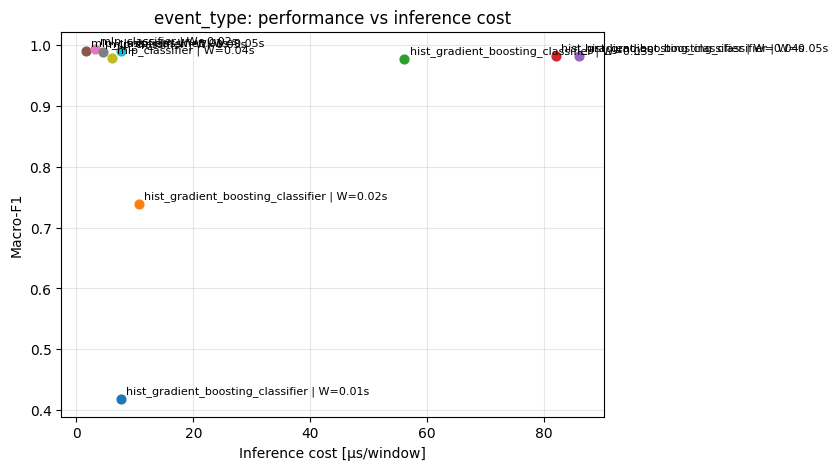

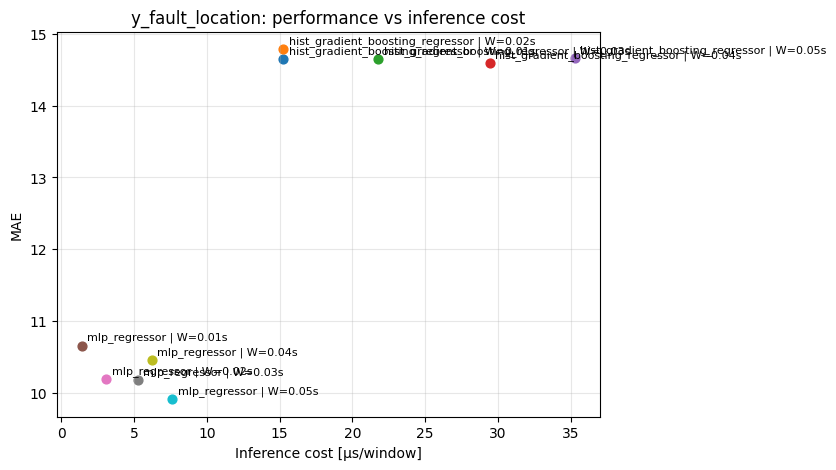

In [212]:

for target_value, perf_col, ylab in [
    ("event_type", "macro_f1", "Macro-F1"),
    ("y_fault_location", "mae", "MAE"),
]:
    if (
        task_col not in plot_df.columns
        or perf_col not in plot_df.columns
        or "infer_us_per_window" not in plot_df.columns
    ):
        print(f"Skipping {target_value} plot due to missing columns")
        continue

    sub = plot_df[plot_df[task_col] == target_value].copy()
    if sub.empty:
        print(f"Skipping {target_value} plot due to empty subset")
        continue

    fig, ax = plt.subplots(figsize=(7, 5))
    for _, r in sub.iterrows():
        label = str(r[model_col]) if model_col in sub.columns else ""
        if window_col in sub.columns:
            label = f"{label} | W={r[window_col]:g}s"
        ax.scatter(r["infer_us_per_window"], r[perf_col], s=40)
        ax.annotate(
            label,
            (r["infer_us_per_window"], r[perf_col]),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points",
        )

    ax.set_xlabel("Inference cost [µs/window]")
    ax.set_ylabel(ylab)
    ax.set_title(f"{target_value}: performance vs inference cost")
    ax.grid(True, alpha=0.3)
    plt.show()

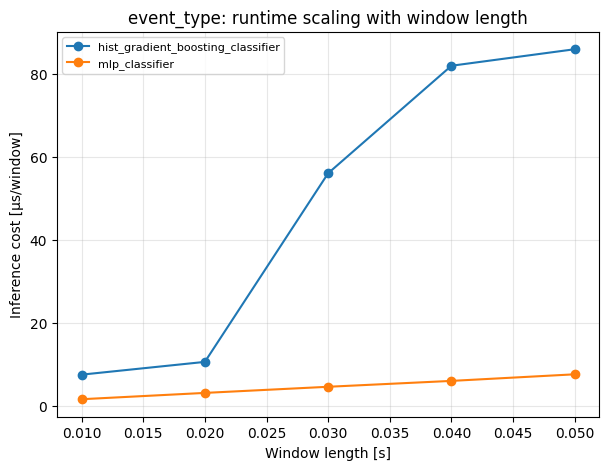

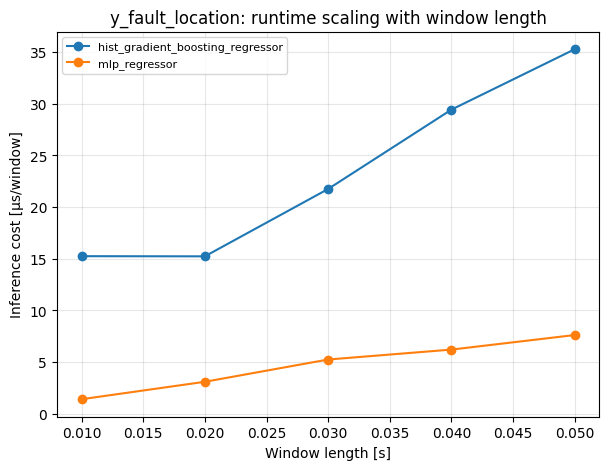

In [213]:
# Cell E: runtime scaling with window length
if all(
    c in runtime_eval.columns
    for c in ["config.model/name", "config.window/length_s", "infer_us_per_window"]
):
    for target_value in sorted(
        runtime_eval["config.task/target_label"].dropna().unique()
    ):
        sub = runtime_eval[
            runtime_eval["config.task/target_label"] == target_value
        ].copy()
        if sub.empty:
            continue

        agg = (
            sub.groupby(["config.model/name", "config.window/length_s"], dropna=False)[
                "infer_us_per_window"
            ]
            .mean()
            .reset_index()
            .sort_values(["config.model/name", "config.window/length_s"])
        )

        fig, ax = plt.subplots(figsize=(7, 5))
        for model_name, g in agg.groupby("config.model/name"):
            ax.plot(
                g["config.window/length_s"],
                g["infer_us_per_window"],
                marker="o",
                label=model_name,
            )

        ax.set_xlabel("Window length [s]")
        ax.set_ylabel("Inference cost [µs/window]")
        ax.set_title(f"{target_value}: runtime scaling with window length")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        plt.show()

In [214]:
# Cell F: simple ranking tables you can paste into the paper
# fastest models per task/window + best performance/runtime trade-off view

rank_cols = [
    c
    for c in [
        "config.model/name",
        "config.task/target_label",
        "config.window/length_s",
        "fit_time_s",
        "infer_us_per_window",
        "throughput_windows_per_s",
        "macro_f1",
        "mae",
    ]
    if c in runtime_eval.columns
]

ranking_df = runtime_eval[rank_cols].copy()

if "infer_us_per_window" in ranking_df.columns:
    print("Fastest by inference cost")
    display(
        ranking_df.sort_values(
            [
                c
                for c in [
                    "config.task/target_label",
                    "config.window/length_s",
                    "infer_us_per_window",
                ]
                if c in ranking_df.columns
            ]
        )
    )

if "macro_f1" in ranking_df.columns and "infer_us_per_window" in ranking_df.columns:
    fc = ranking_df[ranking_df["config.task/target_label"] == "fault_class"].copy()
    if not fc.empty:
        fc["f1_per_us"] = fc["macro_f1"] / fc["infer_us_per_window"]
        print("FC efficiency ranking (higher is better)")
        display(fc.sort_values("f1_per_us", ascending=False))

if "mae" in ranking_df.columns and "infer_us_per_window" in ranking_df.columns:
    fl = ranking_df[ranking_df["config.task/target_label"] == "y_fault_location"].copy()
    if not fl.empty:
        fl["mae_x_us"] = fl["mae"] * fl["infer_us_per_window"]  # lower is better
        print("FL efficiency ranking (lower is better)")
        display(fl.sort_values("mae_x_us", ascending=True))

Fastest by inference cost


,config.model/name,config.task/target_label,config.window/length_s,fit_time_s,infer_us_per_window,throughput_windows_per_s,macro_f1,mae
578,mlp_classifier,event_type,0.01,144.435392,1.618176,618108.133805,0.989434,NaN
575,hist_gradient_boosting_classifier,event_type,0.01,29.312637,7.544870,132555.388562,0.418111,NaN
582,mlp_classifier,event_type,0.02,419.682422,3.126524,322747.835383,0.992808,NaN
574,mlp_classifier,event_type,0.02,426.816466,3.155953,317511.498026,0.992808,NaN
581,hist_gradient_boosting_classifier,event_type,0.02,70.974917,10.486194,96429.918481,0.738005,NaN
573,hist_gradient_boosting_classifier,event_type,0.02,72.808768,10.763235,93583.906222,0.738005,NaN
588,mlp_classifier,event_type,0.03,442.955461,4.620646,217003.120061,0.988766,NaN
585,hist_gradient_boosting_classifier,event_type,0.03,482.977366,56.134810,17816.668479,0.977040,NaN
593,mlp_classifier,event_type,0.04,690.659138,6.039816,165976.803084,0.978410,NaN
589,hist_gradient_boosting_classifier,event_type,0.04,812.161271,82.067717,12386.211648,0.981919,NaN


FL efficiency ranking (lower is better)


,config.model/name,config.task/target_label,config.window/length_s,fit_time_s,infer_us_per_window,throughput_windows_per_s,macro_f1,mae,mae_x_us
577,mlp_regressor,y_fault_location,0.01,40.850568,1.404210,714375.846686,NaN,10.661781,14.971379
580,mlp_regressor,y_fault_location,0.02,190.875876,3.092180,338209.953465,NaN,10.195141,31.525207
584,mlp_regressor,y_fault_location,0.03,470.859649,5.247392,201431.333479,NaN,10.178999,53.413198
587,mlp_regressor,y_fault_location,0.04,951.372974,6.208055,161638.130717,NaN,10.457177,64.918734
591,mlp_regressor,y_fault_location,0.05,1585.957560,7.616661,132184.667257,NaN,9.914551,75.515778
576,hist_gradient_boosting_regressor,y_fault_location,0.01,12.070543,15.248655,67365.292461,NaN,14.646097,223.333282
579,hist_gradient_boosting_regressor,y_fault_location,0.02,22.990697,15.233274,66132.080765,NaN,14.783462,225.200533
583,hist_gradient_boosting_regressor,y_fault_location,0.03,40.202447,21.753925,47660.142385,NaN,14.641933,318.519500
586,hist_gradient_boosting_regressor,y_fault_location,0.04,59.972055,29.433946,34945.381397,NaN,14.590142,429.445453
590,hist_gradient_boosting_regressor,y_fault_location,0.05,81.607852,35.279708,31277.287367,NaN,14.658286,517.140039


In [215]:
# Cell G: optional LaTeX export of the formatted table
formatted_table.to_latex(
    "runtime_table.tex",
    index=False,
    escape=False,
)
print("Saved runtime_table.tex")

Saved runtime_table.tex
